# Employee Turnover Prediction

## Introduction

Employee turnover is a critical challenge for organizations, as it leads to increased recruitment costs, loss of expertise, and reduced productivity. Understanding the factors that contribute to employee attrition can help companies take proactive measures to retain valuable talent.

In this project, we analyze employee data to identify patterns that lead to turnover. We apply machine learning techniques to predict whether an employee is likely to leave the company and propose strategies to improve retention.

## Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from imblearn.over_sampling import SMOTE

## Load Dataset

In [4]:
df = pd.read_csv('/content/HR_comma_sep.csv')
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


## Data Quality Check

We begin by inspecting the dataset to identify missing values, data types, and general structure.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   sales                  14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [6]:
df.isnull().sum()

,0
satisfaction_level,0
last_evaluation,0
number_project,0
average_montly_hours,0
time_spend_company,0
Work_accident,0
left,0
promotion_last_5years,0
sales,0
salary,0


The dataset contains no missing values, and all columns appear to have appropriate data types for further analysis.

## Basic Exploration

We analyze the distribution of employees who stayed versus those who left the company.

In [7]:
df['left'].value_counts()

,count
left,
0,11428
1,3571


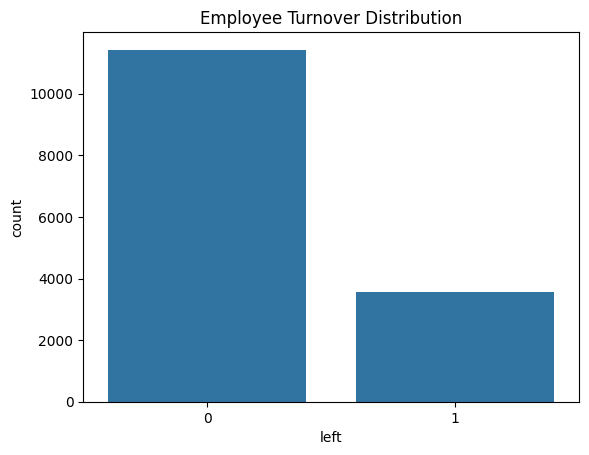

In [8]:
sns.countplot(x='left', data=df)
plt.title("Employee Turnover Distribution")
plt.show()

The dataset shows an imbalance between employees who stayed and those who left. This indicates that class imbalance handling techniques may be necessary during model training.

## Correlation Analysis

We analyze the relationships between numerical features to identify which variables are most associated with employee turnover.

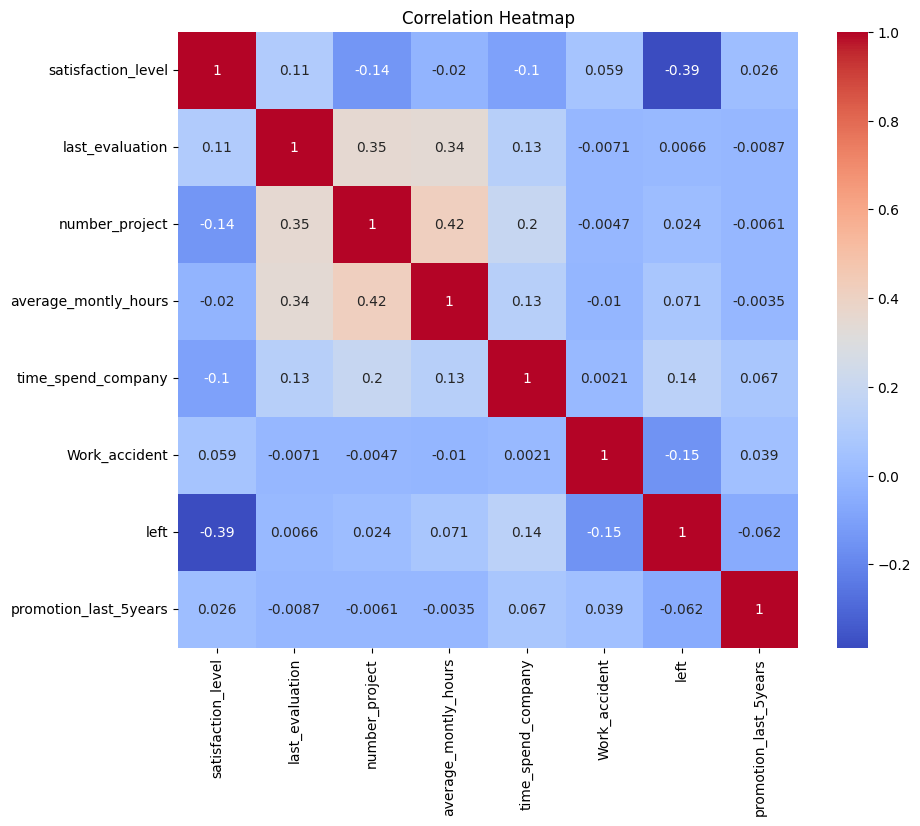

In [9]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

The correlation analysis shows that employee satisfaction level has the strongest relationship with turnover, indicating that less satisfied employees are more likely to leave.

Other variables such as number of projects, evaluation score, and working hours show weak correlations with turnover, suggesting that these factors alone do not strongly determine employee attrition.

Although workload and evaluation may influence employee behavior, the data does not provide sufficient evidence to determine whether these factors directly cause turnover or are influenced by managerial decisions.

##Distribution Analysis

We examine key features to understand employee behavior patterns.

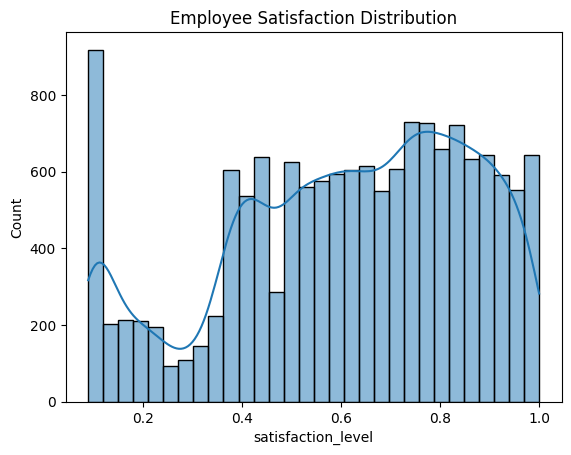

In [10]:
sns.histplot(df['satisfaction_level'], kde=True)
plt.title("Employee Satisfaction Distribution")
plt.show()

Employee satisfaction is widely distributed, with a noticeable concentration at lower values, which may indicate a higher risk of turnover among dissatisfied employees.

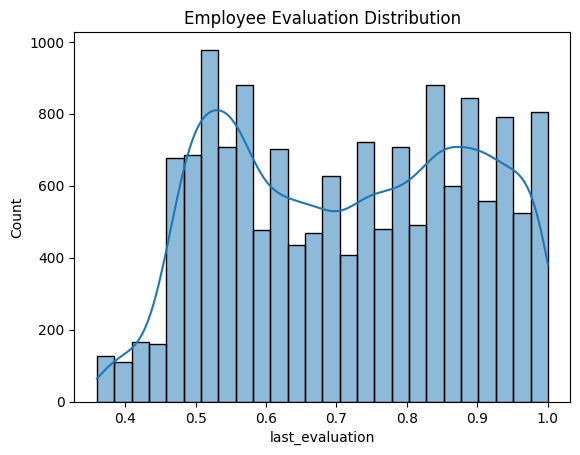

In [11]:
sns.histplot(df['last_evaluation'], kde=True)
plt.title("Employee Evaluation Distribution")
plt.show()

Employee evaluation scores are relatively spread out, suggesting that both high-performing and low-performing employees exist across the organization.

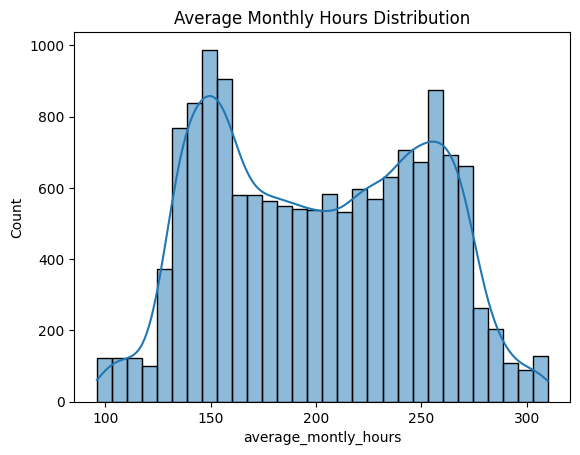

In [12]:
sns.histplot(df['average_montly_hours'], kde=True)
plt.title("Average Monthly Hours Distribution")
plt.show()

The distribution of average monthly hours shows that some employees work significantly more hours than others. This variation may be associated with workload differences, which could influence employee turnover.

## Project Count vs Turnover

We analyze how the number of projects impacts employee turnover

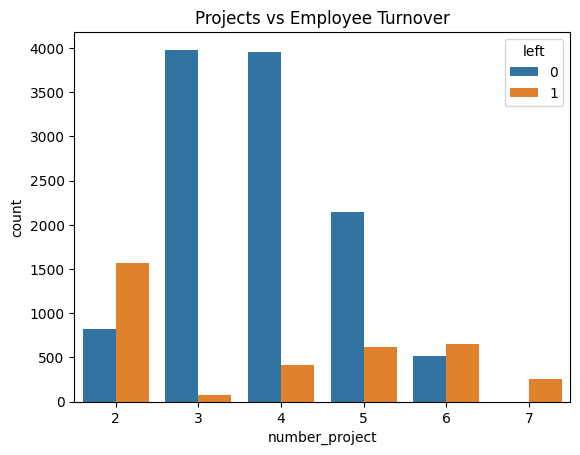

In [13]:
sns.countplot(x='number_project', hue='left', data=df)
plt.title("Projects vs Employee Turnover")
plt.show()

##Key Insight

Employees with a very low or very high number of projects are more likely to leave the company. This suggests that both underutilization and overwork can contribute to employee turnover.

## Clustering Employees Who Left

We apply K-Means clustering to employees who left the company to identify distinct patterns based on satisfaction level and evaluation score.

In [14]:
df_left = df[df['left'] == 1][['satisfaction_level', 'last_evaluation']]
df_left.head()

,satisfaction_level,last_evaluation
0,0.38,0.53
1,0.80,0.86
2,0.11,0.88
3,0.72,0.87
4,0.37,0.52


In [15]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
df_left['cluster'] = kmeans.fit_predict(df_left)

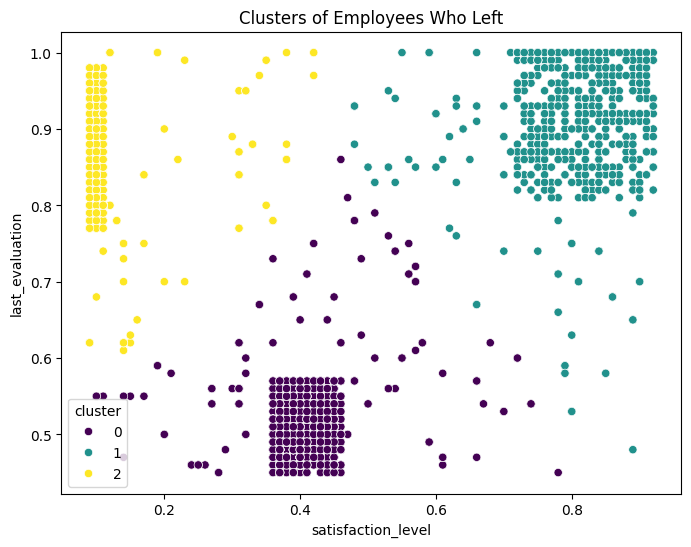

In [16]:
plt.figure  (figsize=(8,6))
sns.scatterplot(
    x='satisfaction_level',
    y='last_evaluation',
    hue='cluster',
    data=df_left,
    palette='viridis'
)
plt.title("Clusters of Employees Who Left")
plt.show()

The clustering results reveal that employee turnover occurs across different groups. While some employees leave due to low satisfaction, there is also a group of high-performing and satisfied employees who still leave the company.

This suggests that employee turnover is influenced by multiple factors beyond satisfaction and performance alone. Additional variables such as career growth, compensation, or external opportunities may play a role, although these are not directly captured in the dataset.

## Column Renaming

The column 'sales' is renamed to 'Department' for better clarity and consistency in the dataset.

In [17]:
df.rename(columns={'sales': "Department"}, inplace=True)

## Data Preprocessing and Handling Class Imbalance

Before training machine learning models, we preprocess the data by encoding categorical variables and addressing class imbalance using the SMOTE technique.

In [18]:
categorical_cols = ["Department", "salary"]
numerical_cols = df.drop(columns=categorical_cols).columns

In [19]:
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df_encoded.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department_RandD,Department_accounting,Department_hr,Department_management,Department_marketing,Department_product_mng,Department_sales,Department_support,Department_technical,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,1,0,False,False,False,False,False,False,True,False,False,True,False
1,0.80,0.86,5,262,6,0,1,0,False,False,False,False,False,False,True,False,False,False,True
2,0.11,0.88,7,272,4,0,1,0,False,False,False,False,False,False,True,False,False,False,True
3,0.72,0.87,5,223,5,0,1,0,False,False,False,False,False,False,True,False,False,True,False
4,0.37,0.52,2,159,3,0,1,0,False,False,False,False,False,False,True,False,False,True,False


In [20]:
X = df_encoded.drop('left', axis=1)
y = df_encoded['left']

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123, stratify=y
)

In [22]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [23]:
y_train.value_counts()

,count
left,
0,9142
1,2857


In [24]:
y_train_smote.value_counts()

,count
left,
0,9142
1,9142


The original dataset showed class imbalance between employees who stayed and those who left. After applying SMOTE, the classes are balanced, which helps prevent the model from being biased toward the majority class.

## Model Training and Evaluation

We train multiple classification models to predict employee turnover and compare their performance using cross-validation and classification metrics.

### Logistic Regression

In [25]:
log_model = LogisticRegression(max_iter=1000)

scores = cross_val_score(
    log_model,
    X_train_smote,
    y_train_smote,
    cv=5,
    scoring='f1'
)

print("F1 Score (CV):", scores.mean())

F1 Score (CV): 0.797931943825487


F1-score was used as the primary evaluation metric because the dataset is imbalanced and both precision and recall are important. Additionally, recall is emphasized to ensure that employees likely to leave are correctly identified, minimizing the risk of losing valuable talent.

In [26]:
log_model.fit(X_train_smote, y_train_smote)
y_pred_log = log_model.predict(X_test)

In [27]:
print(classification_report(y_test,y_pred_log))

              precision    recall  f1-score   support

           0       0.91      0.77      0.83      2286
           1       0.51      0.74      0.60       714

    accuracy                           0.77      3000
   macro avg       0.71      0.76      0.72      3000
weighted avg       0.81      0.77      0.78      3000



Logistic Regression provides a baseline model with balanced performance, but may struggle to capture complex relationships in the data.

### Random Forest Classifier

In [28]:
rf_model = RandomForestClassifier(random_state=42)

scores = cross_val_score(
    rf_model,
    X_train_smote,
    y_train_smote,
    cv=5,
    scoring='f1'
)

print("F1 Score (CV):", scores.mean())

F1 Score (CV): 0.9824830459622206


In [29]:
rf_model.fit(X_train_smote, y_train_smote)
y_pred_rf = rf_model.predict(X_test)

In [30]:
print(classification_report(y_test,y_pred_rf))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2286
           1       0.97      0.98      0.97       714

    accuracy                           0.99      3000
   macro avg       0.98      0.98      0.98      3000
weighted avg       0.99      0.99      0.99      3000



The Random Forest model achieved very high performance across all metrics, indicating strong predictive capability. However, the near-perfect scores suggest the possibility of overfitting or strong feature dominance, and further validation would be required to confirm generalization in real-world scenarios.

In [31]:
pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

,0
satisfaction_level,0.268668
time_spend_company,0.240350
number_project,0.147461
average_montly_hours,0.146049
last_evaluation,0.124316
Work_accident,0.020401
salary_low,0.011341
salary_medium,0.009037
Department_technical,0.006969
Department_support,0.005535


Feature importance analysis shows that satisfaction level and time spent in the company together account for more than 50% of the model's predictive power. This indicates that employee satisfaction and tenure are the primary drivers of turnover in the dataset.

The strong dominance of these meaningful features helps explain the high performance of the Random Forest model. However, given the near-perfect evaluation metrics, caution should be taken to ensure the model generalizes well beyond this dataset.

### Gradient Boosting Classifier

In [32]:
gb_model = GradientBoostingClassifier(random_state=42)

scores = cross_val_score(
    gb_model,
    X_train_smote,
    y_train_smote,
    cv=5,
    scoring='f1'
)

print("F1 Score (CV):", scores.mean())

F1 Score (CV): 0.9611202312266928


In [33]:
gb_model.fit(X_train_smote, y_train_smote)
y_pred_gb = gb_model.predict(X_test)
print(classification_report(y_test, y_pred_gb))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      2286
           1       0.92      0.94      0.93       714

    accuracy                           0.97      3000
   macro avg       0.95      0.96      0.95      3000
weighted avg       0.97      0.97      0.97      3000



Gradient Boosting further enhances predictive performance by sequentially improving weak learners, often achieving higher accuracy and recall compared to other models.

## ROC Curve and AUC Score

The ROC curve is used to evaluate the performance of classification models by measuring their ability to distinguish between classes. The Area Under the Curve (AUC) provides a single metric summarizing this performance.

In [34]:
y_prob_log = log_model.predict_proba(X_test)[:, 1]
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]

In [36]:
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)

In [37]:
auc_log = roc_auc_score(y_test, y_prob_log)
auc_rf = roc_auc_score(y_test, y_prob_rf)
auc_gb = roc_auc_score(y_test, y_prob_gb)

print("Logistics AUC:", auc_log)
print("Random Forest AUC:", auc_rf)
print("Gradient Boosting AUC:", auc_gb)

Logistics AUC: 0.8161608475411162
Random Forest AUC: 0.995377722392544
Gradient Boosting AUC: 0.9855296886908744


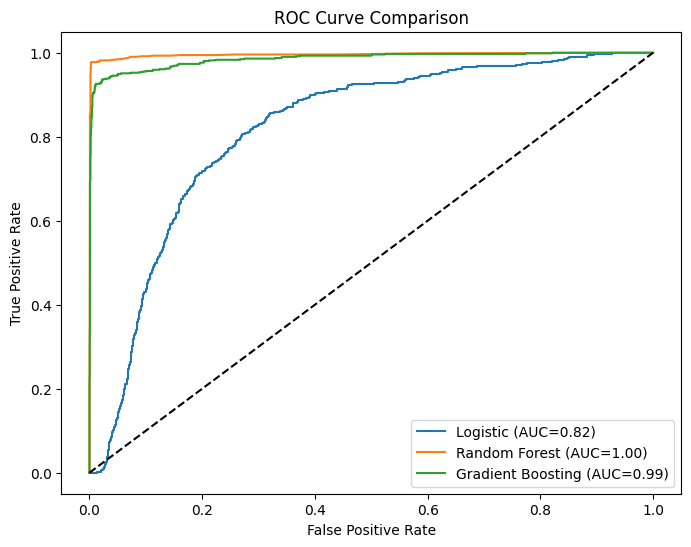

In [42]:
plt.figure(figsize=(8,6))

plt.plot(fpr_log, tpr_log, label=f"Logistic (AUC={auc_log:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={auc_rf:.2f})")
plt.plot(fpr_gb, tpr_gb, label=f"Gradient Boosting (AUC={auc_gb:.2f})")

plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

The ROC curve comparison shows that the Random Forest model achieves the highest AUC score, indicating superior ability to distinguish between employees who leave and those who stay. This confirms that Random Forest is the best-performing model among the ones tested.

## Confusion Matrix

The confusion matrix provides a detailed breakdown of model predictions, showing how many instances were correctly and incorrectly classified for each class.

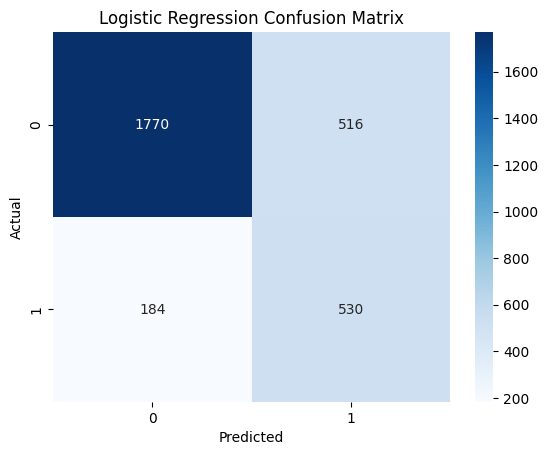

In [43]:
cm_log = confusion_matrix(y_test, y_pred_log)

sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

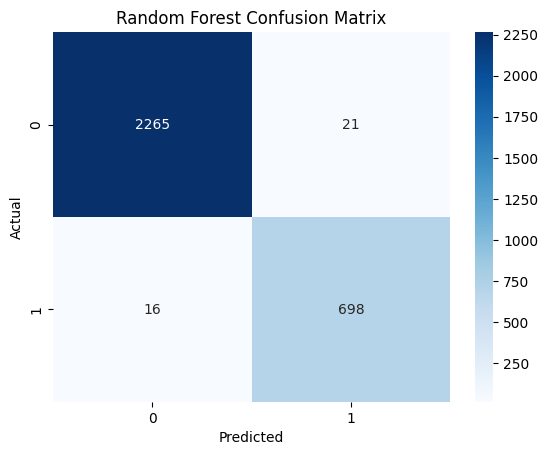

In [44]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

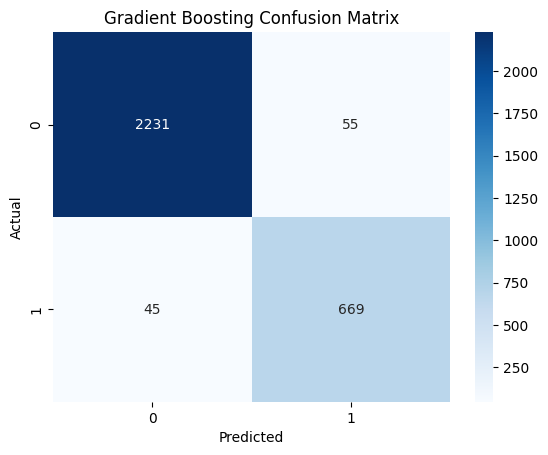

In [45]:
cm_gb = confusion_matrix(y_test, y_pred_gb)

sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Blues')
plt.title("Gradient Boosting Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

The confusion matrix shows that the Random Forest model correctly identifies most employees who leave while minimizing false negatives. This is important because failing to identify employees at risk of leaving could result in loss of valuable talent. Therefore, recall is a critical metric in this context.

## Model Selection

Based on the evaluation metrics, we compare the performance of all models to select the best one for predicting employee turnover.

The Random Forest model outperformed the other models in terms of F1-score, recall, and AUC. It demonstrated strong predictive performance and stability across cross-validation and test data.

Although the model achieved very high accuracy, feature importance analysis suggests that key variables such as employee satisfaction and time spent in the company are strong predictors of turnover. Therefore, Random Forest is selected as the best model for this problem.

## Evaluation Metric Justification

In this problem, recall is considered more important than precision. Identifying employees who are likely to leave is critical for the business, as missing such cases could result in loss of valuable talent.

While precision is also relevant, false positives (predicting an employee will leave when they will not) are less costly compared to false negatives. Therefore, recall is prioritized to ensure that most at-risk employees are identified.

## Employee Retention Strategy

Using the best-performing model (Random Forest), we can estimate the probability of employee turnover and categorize employees into different risk zones.

In [46]:
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

In [48]:
df_results = X_test.copy()
df_results['turnover_probability'] = y_prob_rf

def categorize_risk(p):
  if p < 0.2:
    return 'Safe'
  elif p < 0.6:
    return 'Low Risk'
  elif p < 0.9:
    return 'Medium Risk'
  else:
    return "High Risk"

df_results['risk_zone'] = df_results['turnover_probability'].apply(categorize_risk)
df_results[['turnover_probability', 'risk_zone']].head()

,turnover_probability,risk_zone
10627,0.00,Safe
2703,0.67,Medium Risk
6059,0.03,Safe
3258,0.00,Safe
4565,0.00,Safe


In [49]:
df_results['risk_zone'].value_counts(normalize=True)

,proportion
risk_zone,
Safe,0.727000
High Risk,0.220000
Low Risk,0.038333
Medium Risk,0.014667


Employees can be categorized into different risk zones based on their predicted probability of leaving:

- Safe Zone (<20%): Employees are unlikely to leave and require minimal intervention.
- Low-Risk Zone (20–60%): Employees may require engagement initiatives such as feedback sessions and career discussions.
- Medium-Risk Zone (60–90%): Employees are at risk and should be targeted with retention strategies such as workload adjustments, recognition, and growth opportunities.
- High-Risk Zone (>90%): Immediate action is required, including compensation review, role changes, or direct intervention from management.

This segmentation allows organizations to proactively address employee turnover and allocate resources effectively.

## Conclusion

This project successfully applied machine learning techniques to predict employee turnover and identify key factors influencing employee attrition.

The analysis showed that employee satisfaction and tenure are major drivers of turnover. The Random Forest model achieved the best performance and was used to estimate turnover probabilities.

By combining predictive modeling with actionable insights, organizations can implement targeted retention strategies to reduce employee attrition and improve overall workforce stability.